# 04 — PCA (Principal Component Analysis)
**Inputs:** `data/docs_sampled.csv`, `data/hc3_TFIDF_L2.csv`

**Outputs:** `data/hc3_PCA_DCM.csv`, `data/hc3_PCA_LOADINGS.csv`

**Images:** `images/pca_docs_pc0_pc1.png`, `images/pca_loadings_pc0_pc1.png`, `images/pca_docs_pc2_pc3.png`, `images/pca_loadings_pc2_pc3.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'human':'#4C72B0', 'chatgpt':'#DD8452'}
print('Libraries loaded.')

Libraries loaded.


In [2]:
docs_sampled = pd.read_csv('../data/docs_sampled.csv')
TFIDF_L2= pd.read_csv('../data/hc3_TFIDF_L2.csv', index_col=0)
meta = docs_sampled.set_index('doc_id')[['author_type','source']]

print(f'TFIDF_L2: {TFIDF_L2.shape}')

TFIDF_L2: (10258, 2000)


## Fit PCA

In [3]:
N_COMPONENTS = 10
pca= PCA(n_components=N_COMPONENTS, random_state=42)
pca_scores = pca.fit_transform(TFIDF_L2.values)

comp_cols = [f'PC{i}' for i in range(N_COMPONENTS)]
PCA_DCM= pd.DataFrame(pca_scores, index=TFIDF_L2.index, columns=comp_cols)
PCA_LOADINGS = pd.DataFrame(pca.components_, index=comp_cols, columns=TFIDF_L2.columns)

print('Explained variance ratio (first 5):')
for i, v in enumerate(pca.explained_variance_ratio_[:5]):
    print(f'  PC{i}: {v:.3f}')

print('\nTop 5 positive terms — PC0:', PCA_LOADINGS.loc['PC0'].nlargest(5).index.tolist())
print('Top 5 negative terms — PC0:', PCA_LOADINGS.loc['PC0'].nsmallest(5).index.tolist())
print('\nTop 5 positive terms — PC1:', PCA_LOADINGS.loc['PC1'].nlargest(5).index.tolist())
print('Top 5 negative terms — PC1:', PCA_LOADINGS.loc['PC1'].nsmallest(5).index.tolist())

Explained variance ratio (first 5):
  PC0: 0.007
  PC1: 0.006
  PC2: 0.006
  PC3: 0.005
  PC4: 0.005

Top 5 positive terms — PC0: ['water', 'n', 'air', 'body', 'like']
Top 5 negative terms — PC0: ['stock', 'money', 'company', 'tax', 'price']

Top 5 positive terms — PC1: ['people', 'n', 'like', 'would', 'money']
Top 5 negative terms — PC1: ['water', 'may', 'body', 'cause', 'blood']


In [4]:
PCA_DCM.index.name = 'doc_id'
PCA_DCM.to_csv('../data/hc3_PCA_DCM.csv')
PCA_LOADINGS.index.name = 'component'
PCA_LOADINGS.to_csv('../data/hc3_PCA_LOADINGS.csv')
print('Saved PCA tables.')

Saved PCA tables.


## PCA Visualization 1 — PC0 vs PC1

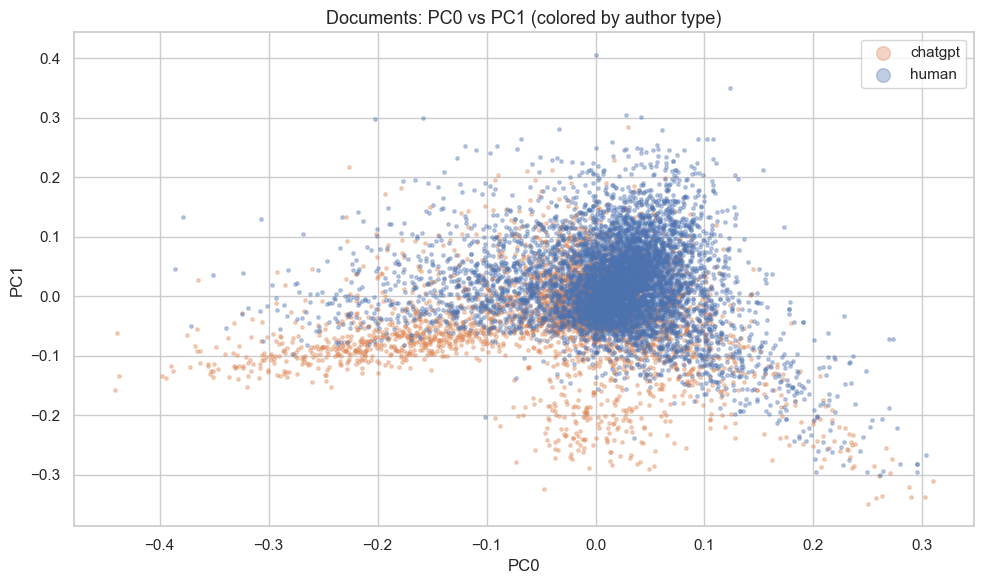

Saved images/pca_docs_pc0_pc1.png


In [5]:
plot_df= PCA_DCM.join(meta)

# --- Documents plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for atype, grp in plot_df.groupby('author_type'):
    ax.scatter(grp['PC0'], grp['PC1'], c=COLORS[atype],
               label=atype, alpha=0.35, s=6)
ax.set_xlabel('PC0', fontsize=12)
ax.set_ylabel('PC1', fontsize=12)
ax.set_title('Documents: PC0 vs PC1 (colored by author type)', fontsize=13)
ax.legend(markerscale=4, fontsize=11)
plt.tight_layout()
plt.savefig('../images/pca_docs_pc0_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/pca_docs_pc0_pc1.png')

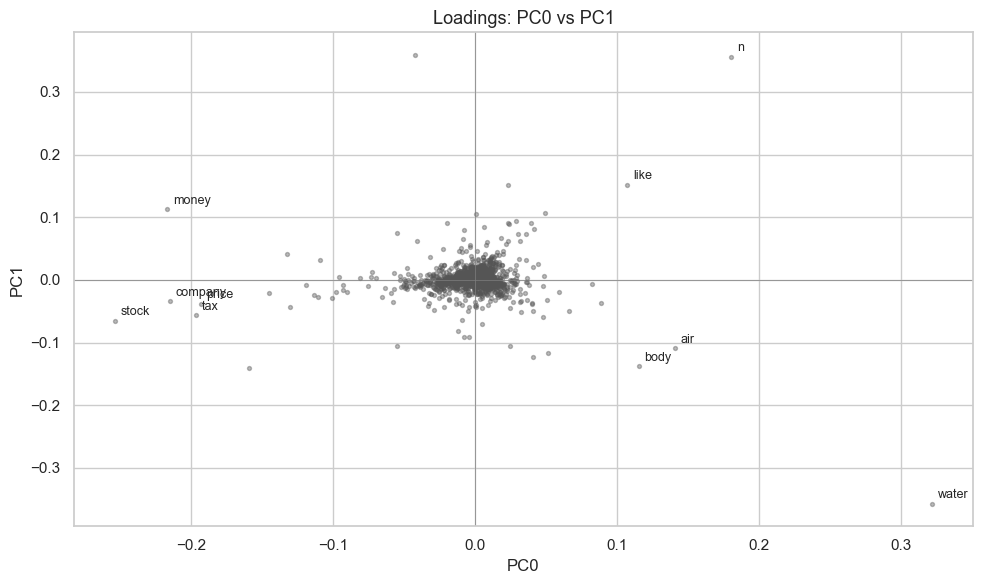

Saved images/pca_loadings_pc0_pc1.png


In [6]:
# --- Loadings plot ---
load_df = pd.DataFrame({
    'term': PCA_LOADINGS.columns,
    'PC0': PCA_LOADINGS.loc['PC0'].values,
    'PC1': PCA_LOADINGS.loc['PC1'].values,
    'PC2': PCA_LOADINGS.loc['PC2'].values,
    'PC3': PCA_LOADINGS.loc['PC3'].values,
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(load_df['PC0'], load_df['PC1'], alpha=0.4, s=8, color='#555')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

label_terms= (PCA_LOADINGS.loc['PC0'].nlargest(5).index.tolist() +
               PCA_LOADINGS.loc['PC0'].nsmallest(5).index.tolist())
for term in label_terms:
    row = load_df[load_df['term'] == term].iloc[0]
    ax.annotate(term, (row['PC0'], row['PC1']), fontsize=9,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC0', fontsize=12)
ax.set_ylabel('PC1', fontsize=12)
ax.set_title('Loadings: PC0 vs PC1', fontsize=13)
plt.tight_layout()
plt.savefig('../images/pca_loadings_pc0_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/pca_loadings_pc0_pc1.png')

## PCA Visualization 2 — PC2 vs PC3

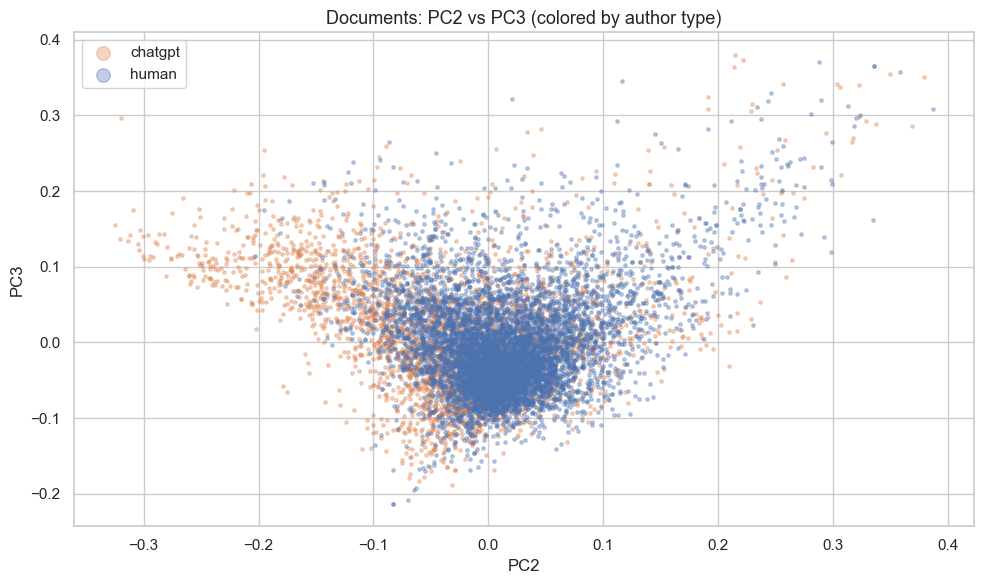

Saved images/pca_docs_pc2_pc3.png


In [7]:
# --- Documents plot ---
fig, ax= plt.subplots(figsize=(10, 6))
for atype, grp in plot_df.groupby('author_type'):
    ax.scatter(grp['PC2'], grp['PC3'], c=COLORS[atype],
               label=atype, alpha=0.35, s=6)
ax.set_xlabel('PC2', fontsize=12)
ax.set_ylabel('PC3', fontsize=12)
ax.set_title('Documents: PC2 vs PC3 (colored by author type)', fontsize=13)
ax.legend(markerscale=4, fontsize=11)
plt.tight_layout()
plt.savefig('../images/pca_docs_pc2_pc3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/pca_docs_pc2_pc3.png')

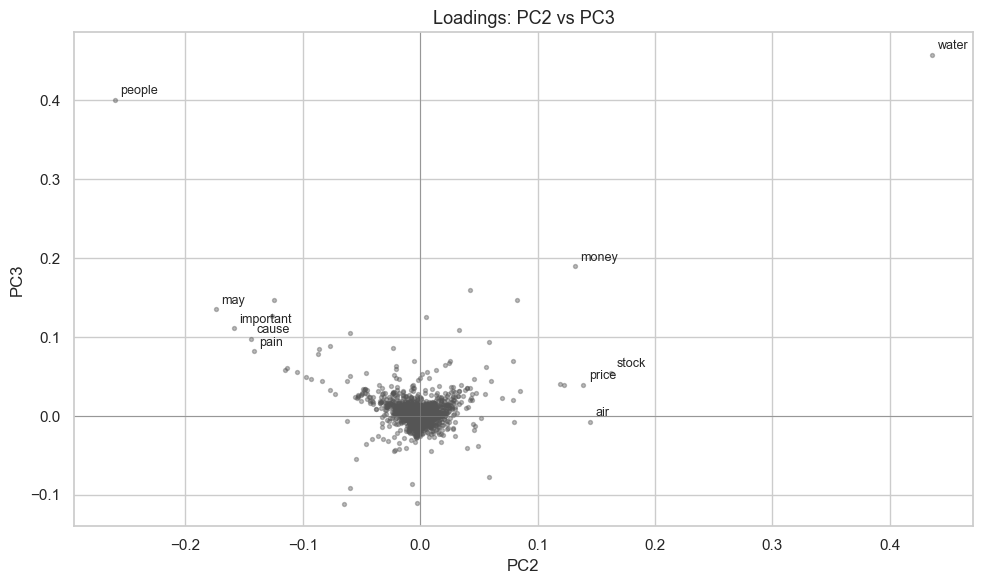

Saved images/pca_loadings_pc2_pc3.png


In [8]:
# --- Loadings plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(load_df['PC2'], load_df['PC3'], alpha=0.4, s=8, color='#555')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

label_terms= (PCA_LOADINGS.loc['PC2'].nlargest(5).index.tolist() +
               PCA_LOADINGS.loc['PC2'].nsmallest(5).index.tolist())
for term in label_terms:
    row = load_df[load_df['term'] ==term].iloc[0]
    ax.annotate(term, (row['PC2'], row['PC3']), fontsize=9,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC2', fontsize=12)
ax.set_ylabel('PC3', fontsize=12)
ax.set_title('Loadings: PC2 vs PC3', fontsize=13)
plt.tight_layout()
plt.savefig('../images/pca_loadings_pc2_pc3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/pca_loadings_pc2_pc3.png')